In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

In [25]:
ndvi_path = "/Users/tillweiss/Desktop/MODSNOW/data/NDVI_nc/NDVI_clean.nc"
ds_ndvi = xr.open_dataset(ndvi_path, engine="h5netcdf")

ndvi = ds_ndvi["ndvi_clean"]

ndvi_doy_start = 200
ndvi_doy_end = 260

doy = ndvi["time"].dt.dayofyear
mask = (doy >= ndvi_doy_start) & (doy <= ndvi_doy_end)

ndvi_window = ndvi.where(mask)
mean_ndvi = ndvi_window.mean(dim="time", skipna=True)

In [26]:
ds_ndvi

<xarray.Dataset> Size: 4GB
Dimensions:     (time: 588, lat: 1081, lon: 1601)
Coordinates:
  * time        (time) object 5kB 2000-02-18 00:00:00 ... 2025-08-29 00:00:00
  * lat         (lat) float64 9kB 43.33 43.33 43.33 43.33 ... 41.09 41.09 41.08
  * lon         (lon) float64 13kB 58.17 58.17 58.17 58.17 ... 61.5 61.5 61.5
Data variables:
    ndvi_clean  (time, lat, lon) float32 4GB ...

In [31]:
def _summary(arr):
    return {
        "n": arr.size,
        "mean": float(np.mean(arr)) if arr.size else np.nan,
        "median": float(np.median(arr)) if arr.size else np.nan,
        "p05": float(np.percentile(arr, 5)) if arr.size else np.nan,
        "p95": float(np.percentile(arr, 95)) if arr.size else np.nan,
    }

In [36]:
ndvi_s = _summary(mean_ndvi)

In [37]:
ndvi_s

{'n': 1730681,
 'mean': 0.3424387276172638,
 'median': nan,
 'p05': nan,
 'p95': nan}

In [11]:
reg_path = "/Users/tillweiss/Desktop/MODSNOW/pixelwise_ndvi_sca_regression_annual_full_ds2.nc"
ds_reg = xr.open_dataset(reg_path)

r2 = ds_reg["r2"]

/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib

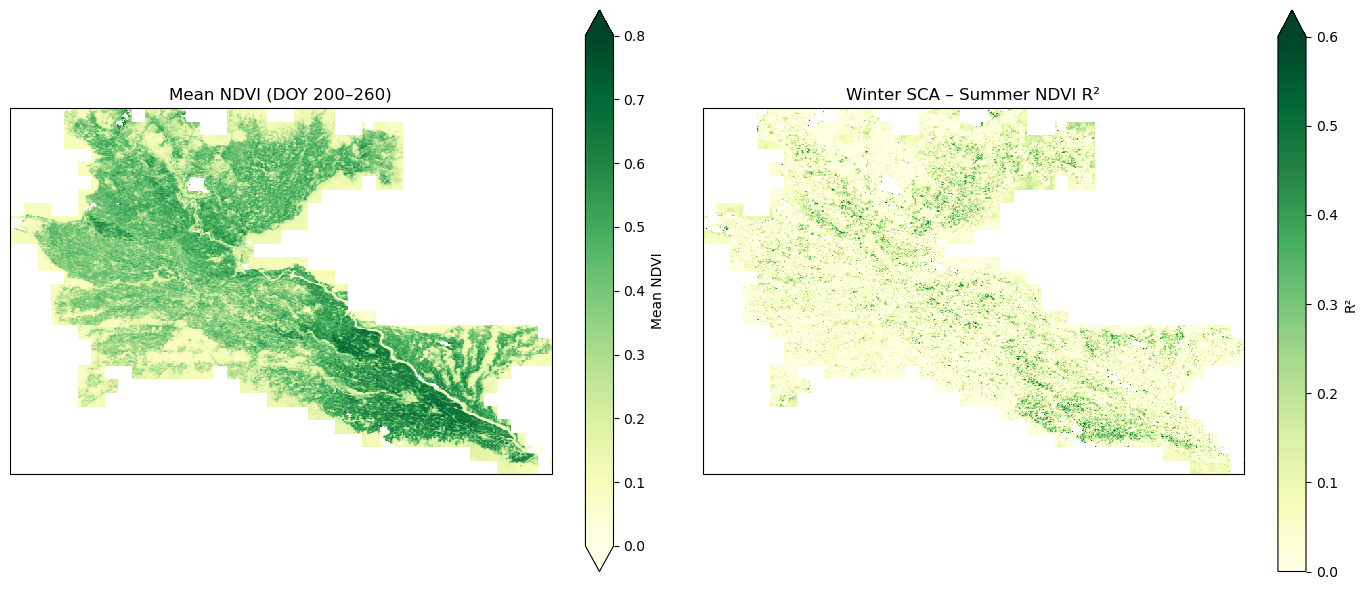

In [13]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 6),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

# ---- LEFT: Mean NDVI ----
mean_ndvi.plot(
    ax=axes[0],
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    vmin=0,
    vmax=0.8,
    cbar_kwargs={'label': 'Mean NDVI'}
)

axes[0].coastlines()
axes[0].set_title('Mean NDVI (DOY 200–260)')


# ---- RIGHT: R² ----
r2.plot(
    ax=axes[1],
    transform=ccrs.PlateCarree(),
    cmap='YlGn',
    vmin=0,
    vmax=0.6,
    cbar_kwargs={'label': 'R²'}
)

axes[1].coastlines()
axes[1].set_title('Winter SCA – Summer NDVI R²')

plt.savefig('ndvi-r2-comp.png', dpi=300)

plt.tight_layout()
plt.show()

In [14]:
ds

<xarray.Dataset> Size: 18MB
Dimensions:         (lat: 540, lon: 800)
Coordinates:
  * lat             (lat) float64 4kB 43.33 43.33 43.32 ... 41.1 41.09 41.09
  * lon             (lon) float64 6kB 58.17 58.17 58.18 ... 61.49 61.49 61.5
Data variables:
    slope           (lat, lon) float64 3MB ...
    intercept       (lat, lon) float64 3MB ...
    r2              (lat, lon) float64 3MB nan nan nan nan ... nan nan nan nan
    n               (lat, lon) int16 864kB ...
    ndvi_mean_raw   (lat, lon) float64 3MB nan nan nan nan ... nan nan nan nan
    ndvi_mean_used  (lat, lon) float64 3MB ...
Attributes:
    ndvi_doy_start:   208
    ndvi_doy_end:     274
    sca_doy_start:    128
    sca_doy_end:      176
    ndvi_anomaly:     none
    sca_metric:       mean
    sca_threshold:    0.1
    chosen_x0:        0
    chosen_y0:        0
    usable_fraction:  0.5032175925925926

/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


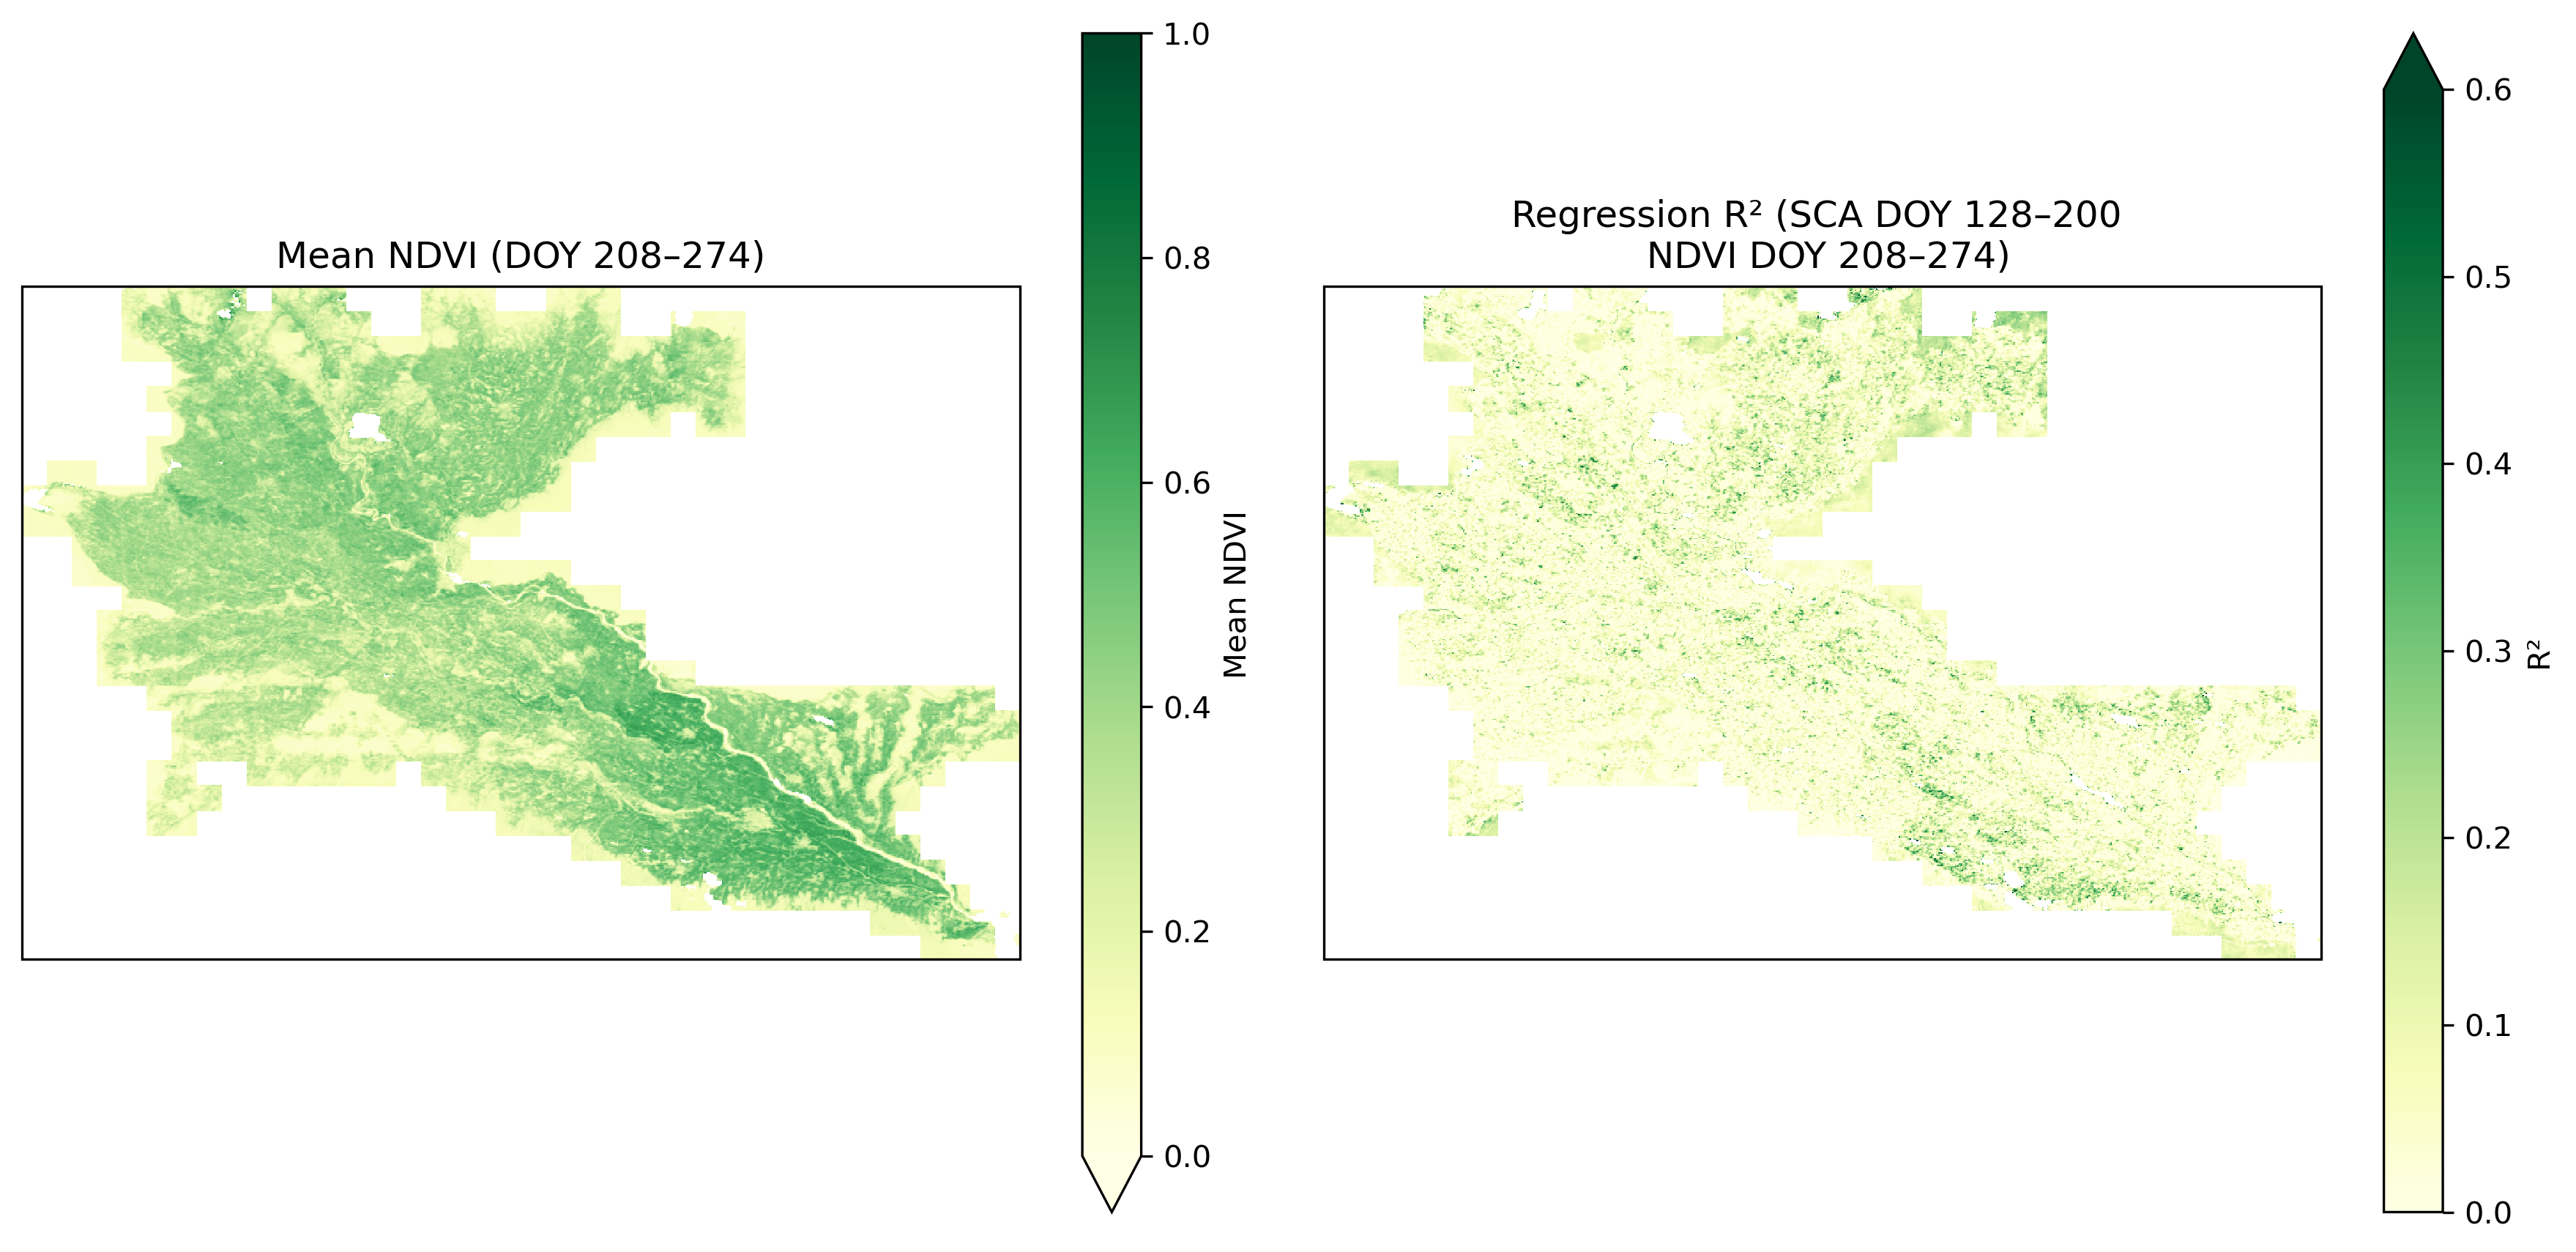

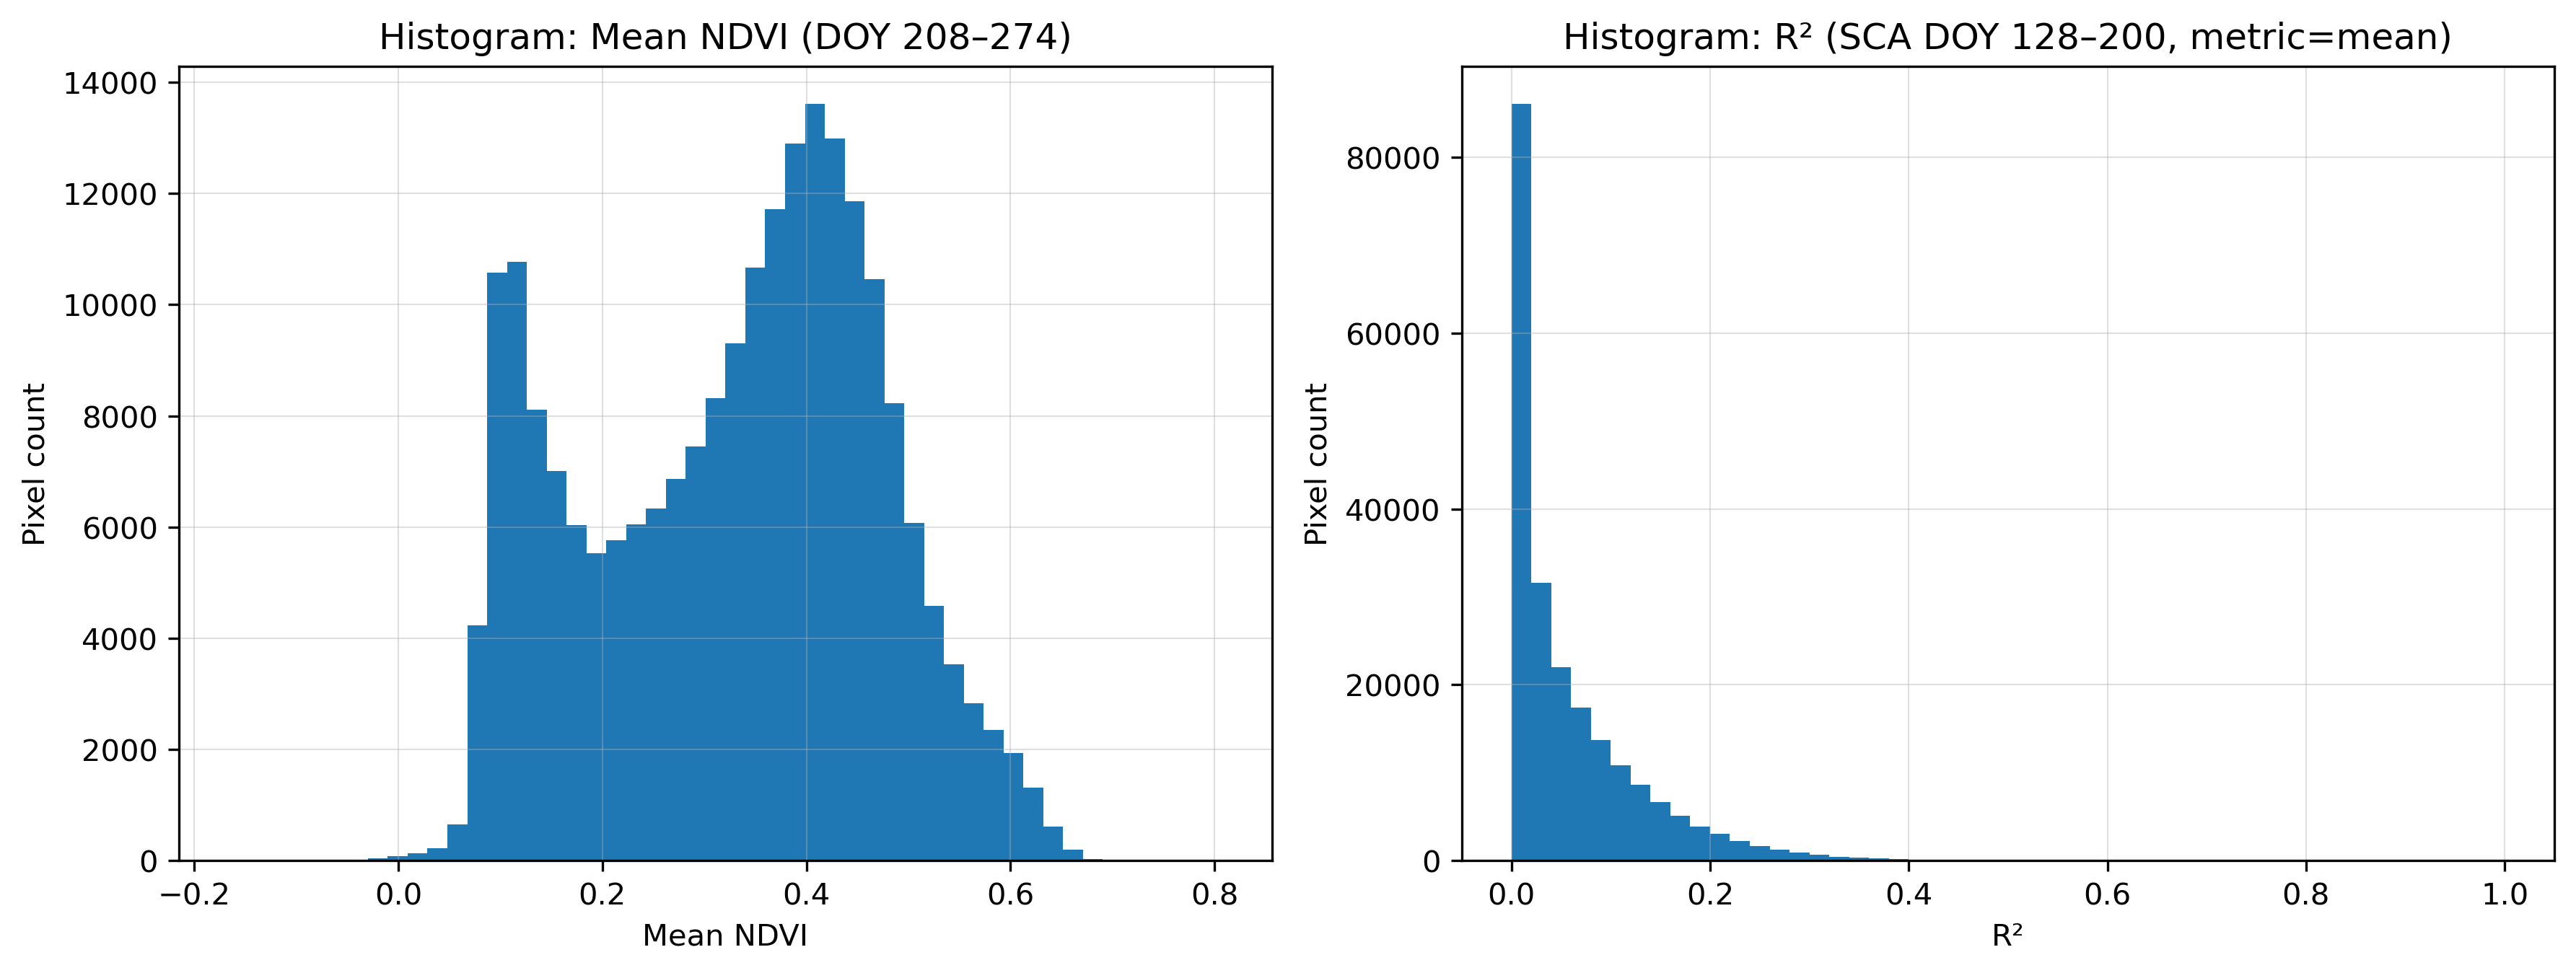

NDVI mean summary: {'n': 219434, 'mean': 0.32898792039017627, 'median': 0.35177625715732574, 'p05': 0.09800253361463547, 'p95': 0.5441573053598403}
R² summary       : {'n': 217390, 'mean': 0.059424177300783636, 'median': 0.03337347800203955, 'p05': 0.00029668734262010564, 'p95': 0.20326081839811921}
Pixels with R² > 0.3: 0.010469662817976908
Pixels with R² > 0.5: 0.0002898017388104329


In [ ]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# -------------------------
# User settings (edit these)
# -------------------------
nc_path = "/Users/tillweiss/Desktop/MODSNOW/pixelwise_late_snow_late_summer_ndvi_full_ds2.nc"

# Put the DOY windows you used in the analysis here so they appear in titles
ndvi_doy_start, ndvi_doy_end = 208, 274
sca_doy_start,  sca_doy_end  = 128, 200
sca_metric = "mean"  # e.g. "mean" / "median" (whatever you used)

# Optional: mask weak regressions for the *map display*
r2_display_min = 0.10

# Optional: NDVI display range (typical)
ndvi_vmin, ndvi_vmax = 0.0, 1.0

# -------------------------
# Load dataset
# -------------------------
ds = xr.open_dataset(nc_path)

# Try to be robust to variable names
if "r2" in ds:
    r2 = ds["r2"]
elif "R2" in ds:
    r2 = ds["R2"]
else:
    raise KeyError("Could not find an R² variable. Looked for: 'r2', 'R2'.")

# If your output already contains ndvi_mean, use it; otherwise compute from an NDVI cube if present
if "ndvi_mean_used" in ds:
    ndvi_mean = ds["ndvi_mean_used"]
elif "ndvi" in ds and "time" in ds["ndvi"].dims:
    ndvi_mean = ds["ndvi"].mean("time", skipna=True)
else:
    raise KeyError("Could not find 'ndvi_mean' and couldn't compute from a time-varying 'ndvi' variable.")

# Identify lat/lon names (common patterns)
lat_name = "lat" if "lat" in ds.coords else ("y" if "y" in ds.coords else None)
lon_name = "lon" if "lon" in ds.coords else ("x" if "x" in ds.coords else None)

# -------------------------
# Prepare masked versions
# -------------------------
# Map display: mask weak fits (keeps histogram unmasked by default)
#r2_map = r2.where(r2 >= r2_display_min)

# Flatten for histograms (finite only)
ndvi_vals = ndvi_mean.values.ravel()
r2_vals   = r2.values.ravel()

ndvi_vals = ndvi_vals[np.isfinite(ndvi_vals)]
r2_vals   = r2_vals[np.isfinite(r2_vals)]

# Simple summaries
def _summary(arr):
    return {
        "n": arr.size,
        "mean": float(np.mean(arr)) if arr.size else np.nan,
        "median": float(np.median(arr)) if arr.size else np.nan,
        "p05": float(np.percentile(arr, 5)) if arr.size else np.nan,
        "p95": float(np.percentile(arr, 95)) if arr.size else np.nan,
    }

ndvi_s = _summary(ndvi_vals)
r2_s   = _summary(r2_vals)

# -------------------------
# Figure 1: paper-ready 2-panel maps
# -------------------------
fig = plt.figure(figsize=(12, 5.8), dpi=300)

ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
im1 = ndvi_mean.plot(
    ax=ax1,
    transform=ccrs.PlateCarree(),
    cmap="YlGn",
    vmin=ndvi_vmin,
    vmax=ndvi_vmax,
    cbar_kwargs={"label": "Mean NDVI"}
)
ax1.coastlines(linewidth=0.8)
ax1.set_title(f"Mean NDVI (DOY {ndvi_doy_start}–{ndvi_doy_end})")

ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
im2 = r2.plot(
    ax=ax2,
    transform=ccrs.PlateCarree(),
    cmap="YlGn",
    vmin=0,
    vmax=0.6,
    cbar_kwargs={"label": "R²"}
)
ax2.coastlines(linewidth=0.8)
ax2.set_title(
    f"Regression R² (SCA DOY {sca_doy_start}–{sca_doy_end} \n NDVI DOY {ndvi_doy_start}–{ndvi_doy_end})"
)

plt.tight_layout()
plt.show()

# -------------------------
# Figure 2: histograms
# -------------------------
fig = plt.figure(figsize=(12, 4.6), dpi=300)

axh1 = plt.subplot(1, 2, 1)
axh1.hist(ndvi_vals, bins=50)
axh1.set_title(f"Histogram: Mean NDVI (DOY {ndvi_doy_start}–{ndvi_doy_end})")
axh1.set_xlabel("Mean NDVI")
axh1.set_ylabel("Pixel count")
axh1.grid(True, linewidth=0.5, alpha=0.4)

axh2 = plt.subplot(1, 2, 2)
axh2.hist(r2_vals, bins=50, range=(0, 1))
axh2.set_title(
    f"Histogram: R² (SCA DOY {sca_doy_start}–{sca_doy_end}, metric={sca_metric})"
)
axh2.set_xlabel("R²")
axh2.set_ylabel("Pixel count")
axh2.grid(True, linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()

# -------------------------
# Print quick stats (handy for your write-up/email)
# -------------------------
print("NDVI mean summary:", ndvi_s)
print("R² summary       :", r2_s)
print("Pixels with R² > 0.3:", float(np.mean(r2_vals > 0.3)))
print("Pixels with R² > 0.5:", float(np.mean(r2_vals > 0.5)))

In [22]:
import xarray as xr

nc_path = "/Users/tillweiss/Desktop/MODSNOW/pixelwise_late_snow_late_summer_ndvi_anomaly2.nc"  # change to yours
ds = xr.open_dataset(nc_path)
print(ds)
print("data_vars:", list(ds.data_vars))

<xarray.Dataset> Size: 87MB
Dimensions:             (lat: 1081, lon: 1601)
Coordinates:
  * lat                 (lat) float64 9kB 43.33 43.33 43.33 ... 41.09 41.08
  * lon                 (lon) float64 13kB 58.17 58.17 58.17 ... 61.5 61.5 61.5
Data variables:
    slope               (lat, lon) float64 14MB ...
    intercept           (lat, lon) float64 14MB ...
    r2                  (lat, lon) float64 14MB ...
    n                   (lat, lon) int16 3MB ...
    ndvi_mean_raw       (lat, lon) float64 14MB ...
    ndvi_mean_used      (lat, lon) float64 14MB ...
    ndvi_longterm_mean  (lat, lon) float64 14MB ...
Attributes:
    ndvi_doy_start:   220
    ndvi_doy_end:     280
    sca_doy_start:    140
    sca_doy_end:      220
    ndvi_anomaly:     demean_pixel
    sca_metric:       last_day_above
    sca_threshold:    0.1
    chosen_x0:        0
    chosen_y0:        0
    usable_fraction:  0.49495834298752917
data_vars: ['slope', 'intercept', 'r2', 'n', 'ndvi_mean_raw', 'ndvi_mean_us

ndvi_mean_used mean: -3.146605255149355e-11
ndvi_mean_used median: 0.0


/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/tillweiss/miniconda3/envs/rs_cryo_env/lib/python3.12/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


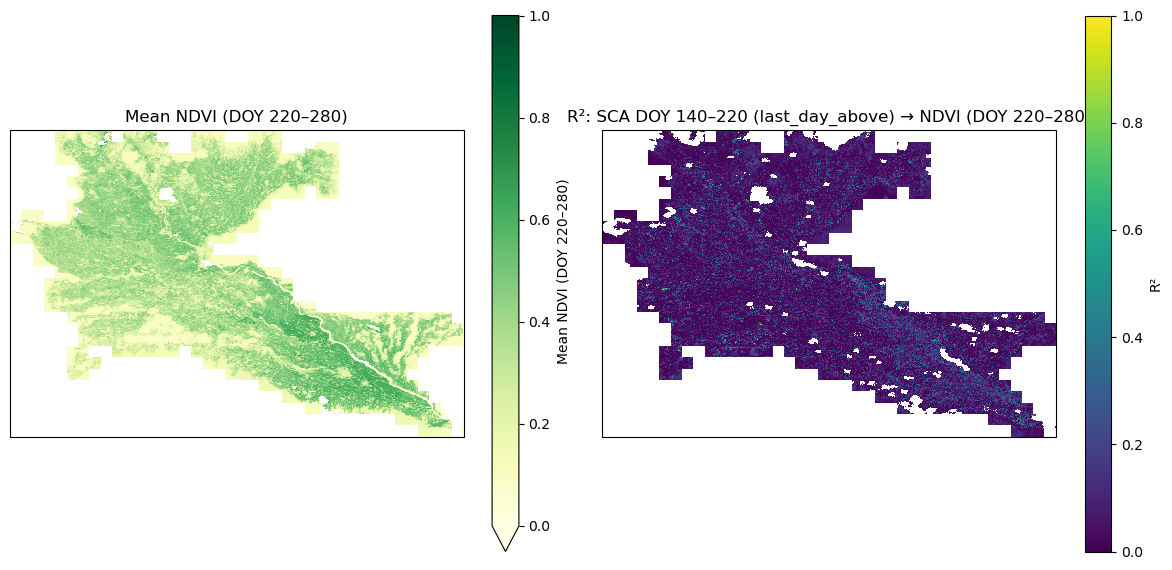

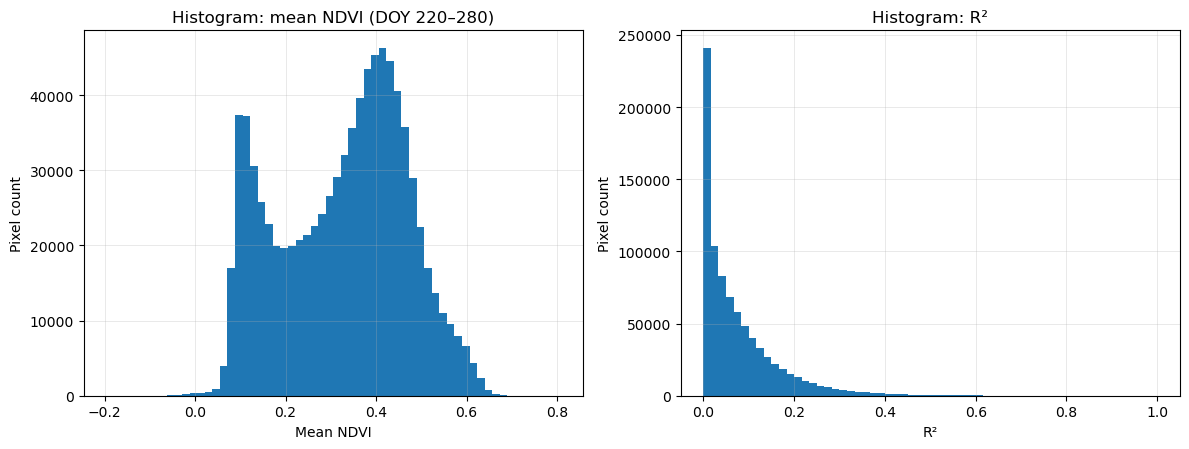

In [24]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

nc_path = "/Users/tillweiss/Desktop/MODSNOW/pixelwise_late_snow_late_summer_ndvi_anomaly2.nc"  # change to yours
ds = xr.open_dataset(nc_path)

doy_str = f"DOY {ds.attrs['ndvi_doy_start']}–{ds.attrs['ndvi_doy_end']}"
sca_str = f"SCA DOY {ds.attrs['sca_doy_start']}–{ds.attrs['sca_doy_end']} ({ds.attrs['sca_metric']})"

# --- sanity: mean anomaly should be ~0 ---
m = ds["ndvi_mean_used"].values
print("ndvi_mean_used mean:", float(np.nanmean(m)))
print("ndvi_mean_used median:", float(np.nanmedian(m)))

# --- 2-panel: mean NDVI + R² ---
fig = plt.figure(figsize=(12, 5.8))

ax1 = plt.subplot(1, 2, 1, projection=ccrs.PlateCarree())
ds["ndvi_mean_raw"].plot(
    ax=ax1, transform=ccrs.PlateCarree(),
    cmap="YlGn", vmin=0, vmax=1,
    cbar_kwargs={"label": f"Mean NDVI ({doy_str})"}
)
ax1.coastlines(linewidth=0.8)
ax1.set_title(f"Mean NDVI ({doy_str})")

ax2 = plt.subplot(1, 2, 2, projection=ccrs.PlateCarree())
ds["r2"].plot(
    ax=ax2, transform=ccrs.PlateCarree(),
    cmap="viridis", vmin=0, vmax=1,
    cbar_kwargs={"label": "R²"}
)
ax2.coastlines(linewidth=0.8)
ax2.set_title(f"R²: {sca_str} → NDVI ({doy_str})")

plt.tight_layout()
plt.show()

# --- histograms: NDVI mean + R² ---
ndvi_vals = ds["ndvi_mean_raw"].values.ravel()
r2_vals = ds["r2"].values.ravel()
ndvi_vals = ndvi_vals[np.isfinite(ndvi_vals)]
r2_vals = r2_vals[np.isfinite(r2_vals)]

plt.figure(figsize=(12,4.6))
plt.subplot(1,2,1)
plt.hist(ndvi_vals, bins=60)
plt.title(f"Histogram: mean NDVI ({doy_str})")
plt.xlabel("Mean NDVI")
plt.ylabel("Pixel count")
plt.grid(True, linewidth=0.5, alpha=0.4)

plt.subplot(1,2,2)
plt.hist(r2_vals, bins=60, range=(0,1))
plt.title("Histogram: R²")
plt.xlabel("R²")
plt.ylabel("Pixel count")
plt.grid(True, linewidth=0.5, alpha=0.4)

plt.tight_layout()
plt.show()